# Import Libraries

In [186]:
# Import Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score

# Save Model
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [187]:
df = pd.read_csv("C:\\Users\\Admin\\Documents\\machine_failure\\csv\\machine failure.csv")

# Data Summary

#1.Display First 5 Rows

In [188]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


#2.Display Last 5 Rows

In [189]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


#3.Check Dataset Shape

In [190]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 14)


#4.Dataset Information

In [191]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

#5.Column Names

In [192]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

#6.Data Types

In [193]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

#7.Statistical Summary

In [194]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# Data Cleaning

#Check Missing Values

In [195]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

#Check Duplicate Records

In [196]:
df.duplicated().sum()

np.int64(0)

#Remove Duplicate Records 

In [197]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

#Check Data Types

In [198]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

#Drop Unneccessary Columns

In [199]:
df.drop(['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
        axis=1,
        inplace=True)
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='str')

#Display Cleaned Dataset

In [200]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


# Data Visualization

#1. Distribution of Numerical Features

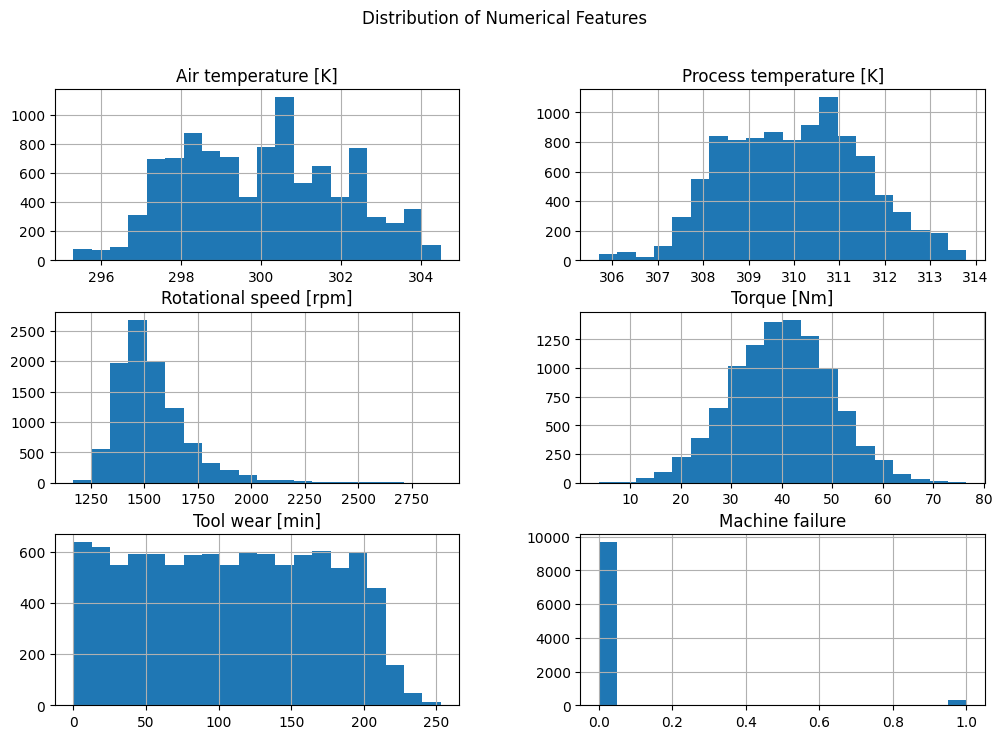

In [201]:
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

#2. Distribution of Machine Types

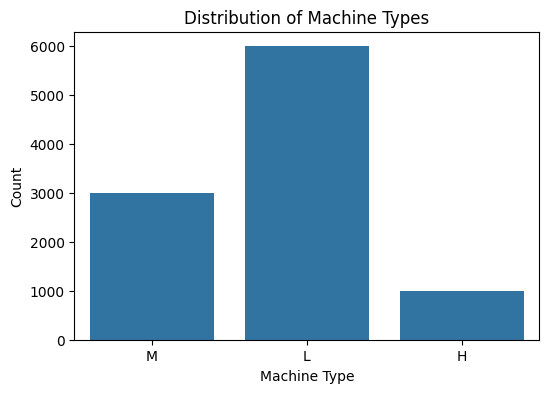

In [202]:
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df)
plt.title("Distribution of Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.show()

#3. Machine Failure Distribution

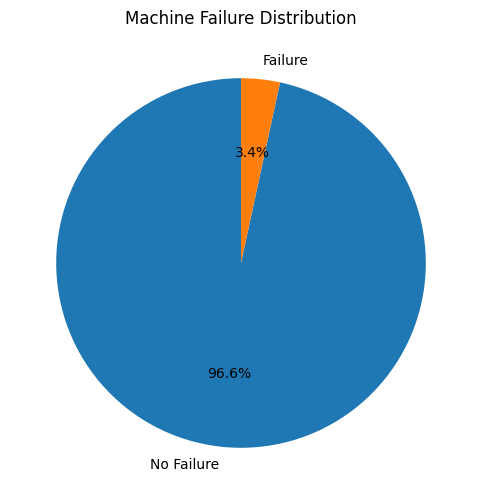

In [203]:
failure = df['Machine failure'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(failure,
        labels=['No Failure','Failure'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Machine Failure Distribution")
plt.show()

#4. Detection of Outliers in Numerical Features

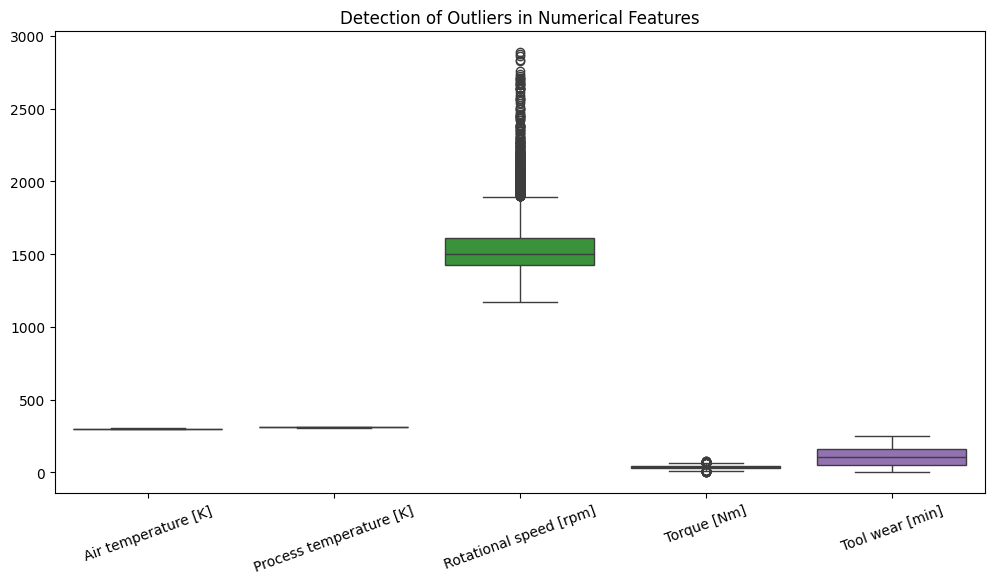

In [204]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Air temperature [K]',
                     'Process temperature [K]',
                     'Rotational speed [rpm]',
                     'Torque [Nm]',
                     'Tool wear [min]']])

plt.title("Detection of Outliers in Numerical Features")
plt.xticks(rotation=20)
plt.show()

#5. Correlation Between Numerical Features

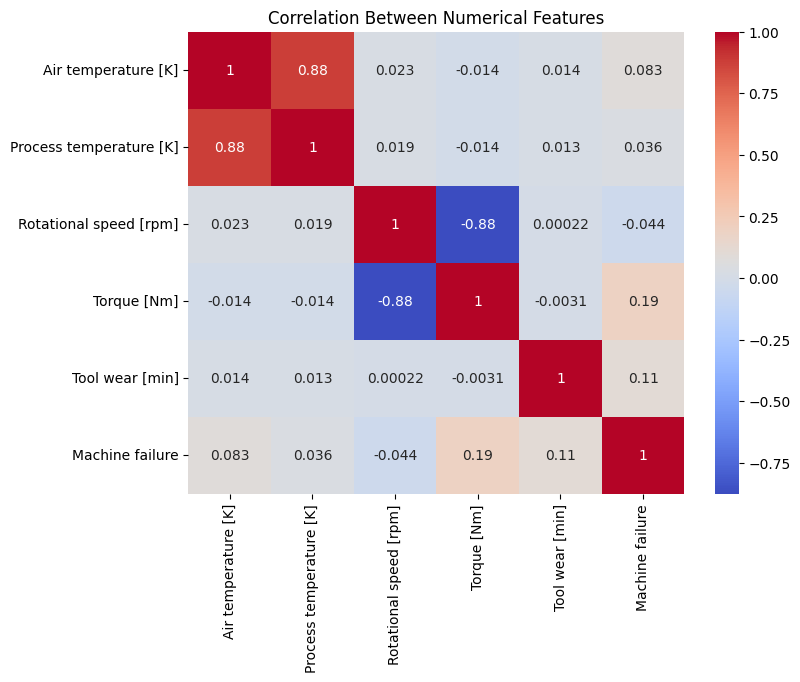

In [205]:

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Between Numerical Features")
plt.show()

#6. Relationship Between Torque and Rotational Speed

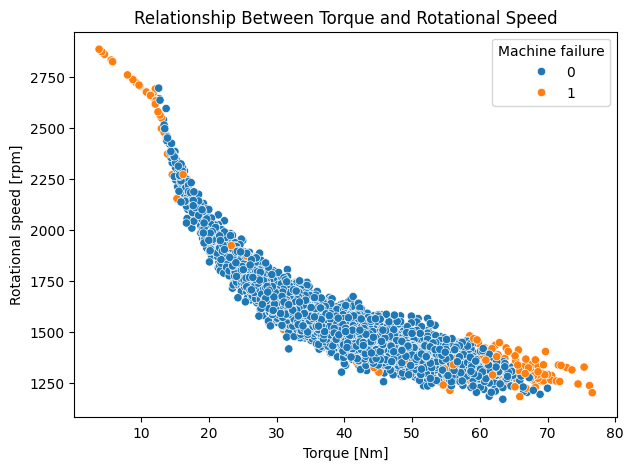

In [206]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Torque [Nm]',
                y='Rotational speed [rpm]',
                hue='Machine failure',
                data=df)

plt.title("Relationship Between Torque and Rotational Speed")
plt.show()

#7. Trend of Tool Wear

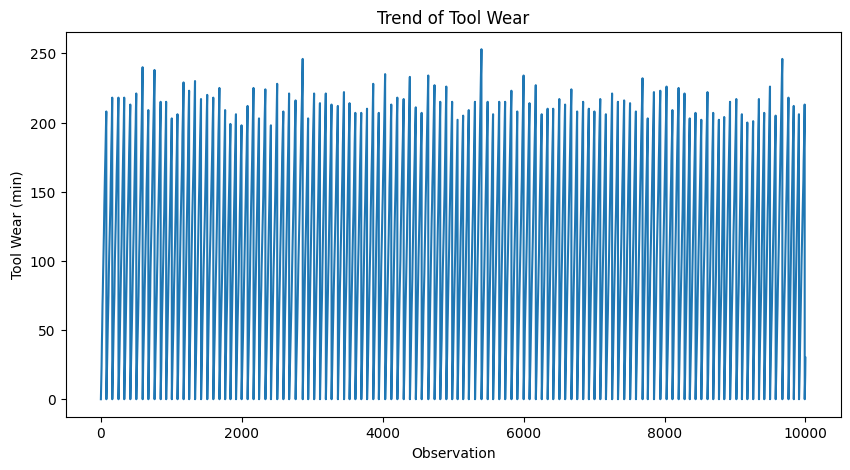

In [207]:
plt.figure(figsize=(10,5))
plt.plot(df['Tool wear [min]'])

plt.title("Trend of Tool Wear")
plt.xlabel("Observation")
plt.ylabel("Tool Wear (min)")
plt.show()

#8. Distribution of Torque Based on Machine Failure

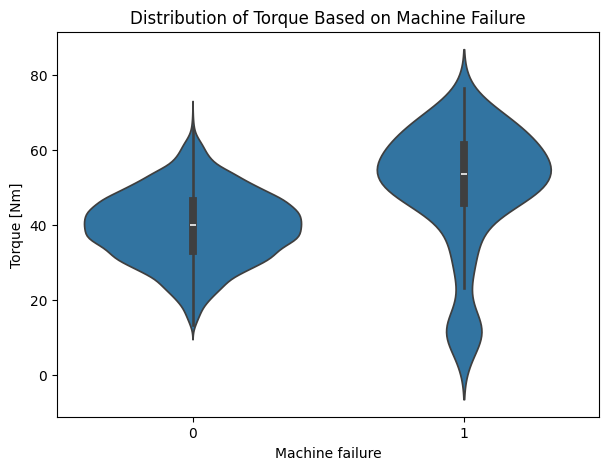

In [208]:
plt.figure(figsize=(7,5))
sns.violinplot(x='Machine failure',
               y='Torque [Nm]',
               data=df)

plt.title("Distribution of Torque Based on Machine Failure")
plt.show()

#9. Pairwise Relationship Between Numerical Features

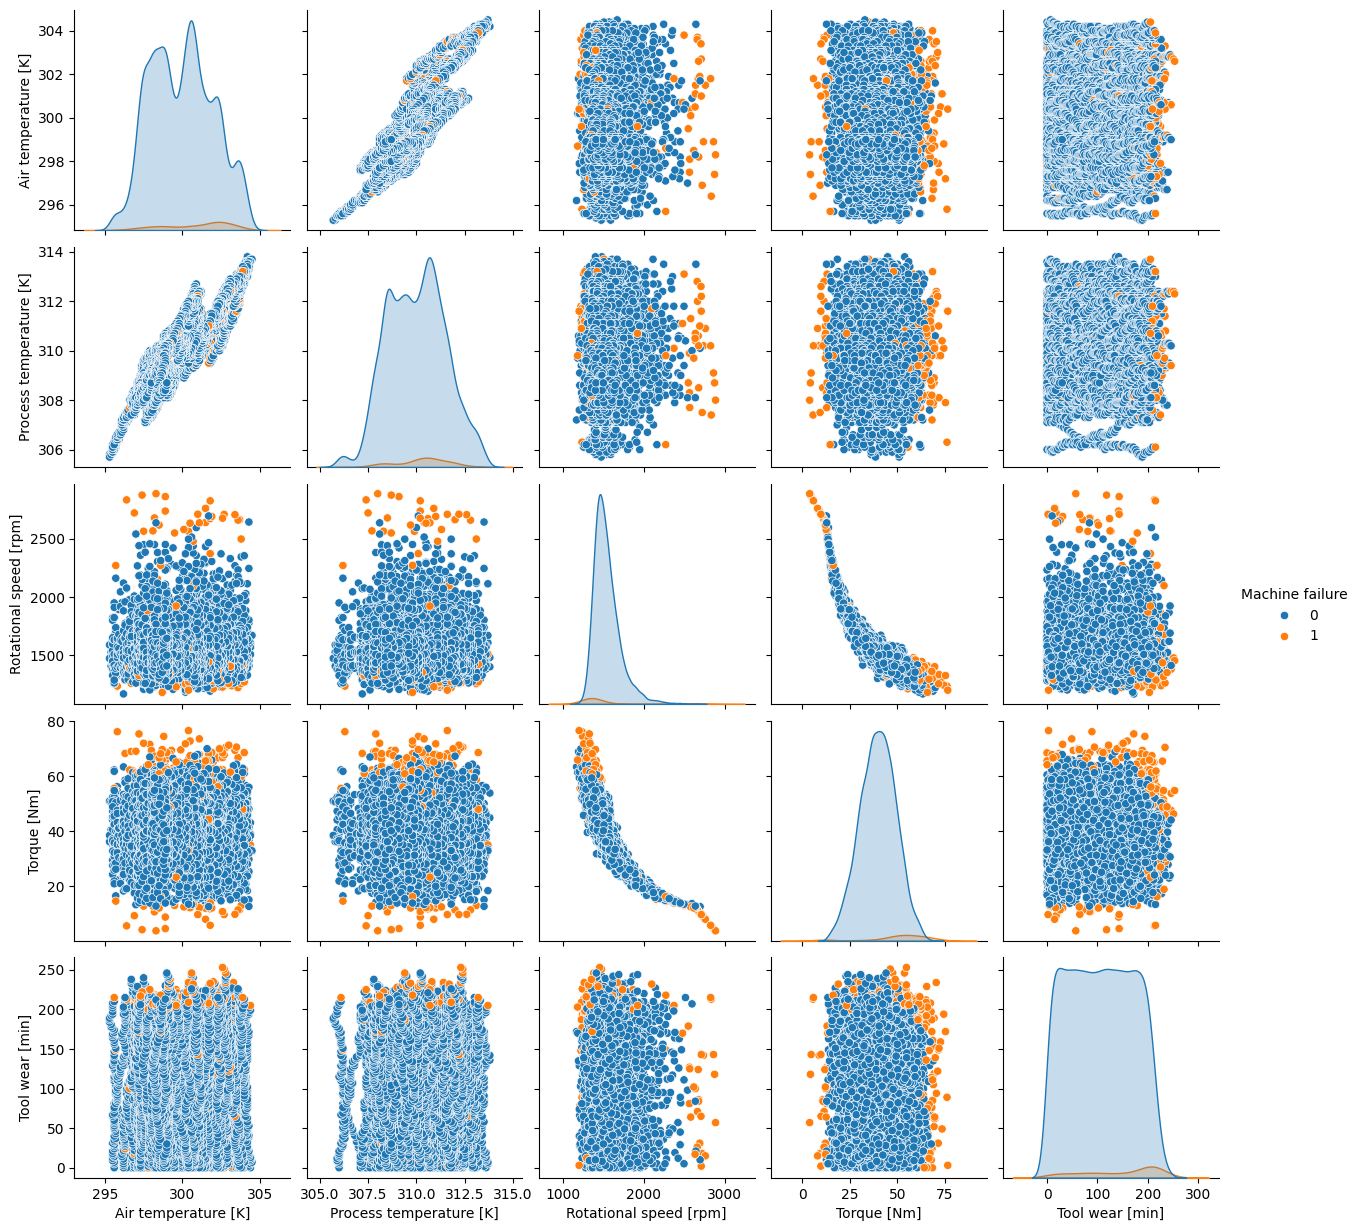

In [209]:
sns.pairplot(df[['Air temperature [K]',
                 'Process temperature [K]',
                 'Rotational speed [rpm]',
                 'Torque [Nm]',
                 'Tool wear [min]',
                 'Machine failure']],
             hue='Machine failure')

plt.show()

#10. Average Torque Across Machine Types

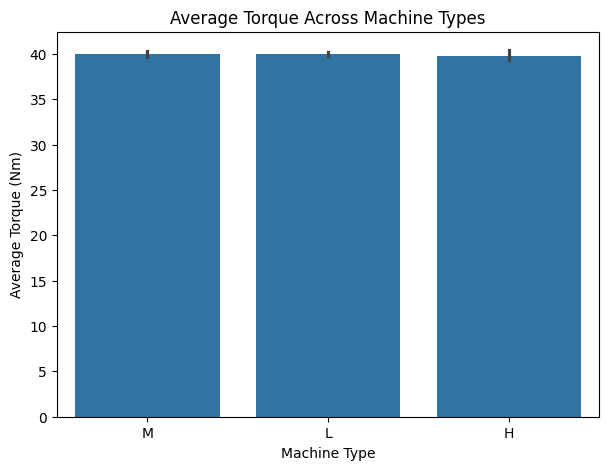

In [210]:
plt.figure(figsize=(7,5))
sns.barplot(x='Type',
            y='Torque [Nm]',
            data=df)

plt.title("Average Torque Across Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Average Torque (Nm)")
plt.show()

#Save Cleaned Data

In [211]:
df.to_csv("cleaned_machine_failure_data.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Feature Engineering

#Check Data Types 

In [212]:
df.dtypes

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object

#Encode Machine Type

In [213]:
le = LabelEncoder()

df['Type'] = le.fit_transform(df['Type'])

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


#Check Encoded Values

In [214]:
df['Type'].unique()

array([2, 1, 0])

#View Label Mapping

In [215]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


# Feature Selection 

In [216]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (10000, 6)
Target Shape : (10000,)


# Data Transformation

#Feature Scaling

In [217]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#Display Scaled Feature

In [218]:
X_scaled[:5]

array([[ 1.33388944e+00, -9.52389443e-01, -9.47359888e-01,
         6.81851403e-02,  2.82199756e-01, -1.69598374e+00],
       [-3.32222777e-01, -9.02393410e-01, -8.79959002e-01,
        -7.29471505e-01,  6.33308020e-01, -1.64885170e+00],
       [-3.32222777e-01, -9.52389443e-01, -1.01476077e+00,
        -2.27449840e-01,  9.44289625e-01, -1.61743034e+00],
       [-3.32222777e-01, -9.02393410e-01, -9.47359888e-01,
        -5.90021043e-01, -4.88451785e-02, -1.58600898e+00],
       [-3.32222777e-01, -9.02393410e-01, -8.79959002e-01,
        -7.29471505e-01,  1.31314491e-03, -1.55458761e+00]])

# Data Split/Partition

In [219]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (8000, 6)
Testing Data : (2000, 6)


# Model Initialization

In [220]:
lr_model = LogisticRegression(random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    random_state=42
)

# Model Training

In [221]:
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


# Model Prediction

In [222]:
lr_prediction = lr_model.predict(X_test)
dt_prediction = dt_model.predict(X_test)
rf_prediction = rf_model.predict(X_test)
svm_prediction = svm_model.predict(X_test)

# Model Evaluation

In [223]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_prediction))
print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_prediction))
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_prediction))
print("SVM Accuracy:",
      accuracy_score(y_test, svm_prediction))

Logistic Regression Accuracy: 0.973
Decision Tree Accuracy: 0.9785
Random Forest Accuracy: 0.984
SVM Accuracy: 0.977


#Compare All Models

In [224]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, rf_prediction),
        accuracy_score(y_test, svm_prediction)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.9730
1        Decision Tree    0.9785
2        Random Forest    0.9840
3                  SVM    0.9770


# Save Model

#save

In [225]:
with open("machine_failure_prediction_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(le, file)

print("Model, Scaler, and Label Encoder saved successfully!")

Model, Scaler, and Label Encoder saved successfully!


#load

In [226]:
with open("machine_failure_prediction_model.pkl", "rb") as file:
    model = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

with open("label_encoder.pkl", "rb") as file:
    le = pickle.load(file)